In [9]:
# N-HiTS Forecasting - Climate Jakarta (FINAL STABLE)
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

In [10]:
# LOAD + PREPROCESS
df = pd.read_csv('climate_jakarta_96745.csv')

df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')

df = df.sort_values('ds').drop_duplicates()
df = df.fillna(method='ffill').fillna(method='bfill')

df['unique_id'] = 'series_1'

df.head()

,ds,y,unique_id
0,2010-01-01,28.7,series_1
1,2010-01-02,28.7,series_1
2,2010-01-03,28.8,series_1
3,2010-01-04,29.9,series_1
4,2010-01-05,28.5,series_1


In [11]:
# SPLIT 70/10/20
n = len(df)

train_end = int(n * 0.7)
val_end   = int(n * 0.8)

train_full = df.iloc[:val_end].copy()
test_df    = df.iloc[val_end:].copy()

len(train_full), len(test_df)

(3203, 801)

In [12]:
# MODEL
horizon = len(test_df)

model = NHITS(
    h=horizon,
    input_size=30,
    max_steps=200,
    early_stop_patience_steps=30
)

Seed set to 1


In [13]:
nf = NeuralForecast(models=[model], freq='D')

# TRAIN
nf.fit(
    df=train_full,
    val_size=horizon
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.2 M  | train
-------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.644    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


In [14]:
# PREDICT
forecast = nf.predict()

y_pred = forecast['NHITS'].values
y_true = test_df['y'].values
ds_test = test_df['ds']

print('Length:', len(y_true), len(y_pred))

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Length: 801 801


In [15]:
# METRICS
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

smape = np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred))
) * 100

naive = np.mean(np.abs(np.diff(y_true)))
mase = mae / naive

print('RMSE:', rmse)
print('MAE :', mae)
print('sMAPE:', smape)
print('MASE :', mase)

RMSE: 1.3475365590880493
MAE : 1.0785169160916712
sMAPE: 3.7257154297038895
MASE : 1.7764330510054291


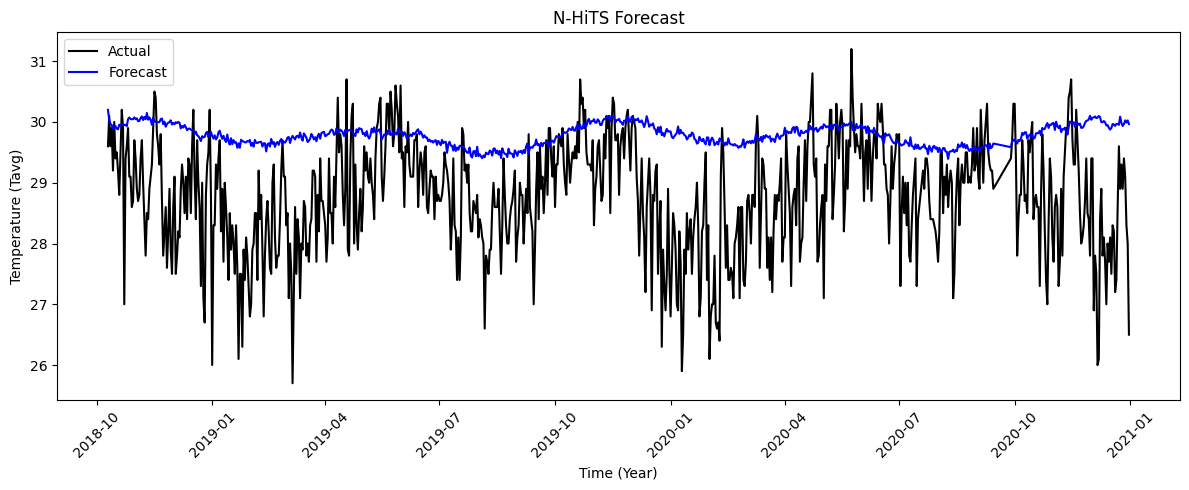

In [18]:
plt.figure(figsize=(12,5))

plt.plot(ds_test, y_true, label='Actual', color='black')
plt.plot(ds_test, y_pred, label='Forecast', color='blue')

plt.title('N-HiTS Forecast')
plt.xlabel('Time (Year)')
plt.ylabel('Temperature (Tavg)')

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()